In this file, we want to see if we can reproduce some of the results from the Molmer paper.

In [172]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.cm as cm

In [191]:
# Set font size of plot elements\n",
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 18
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

### Fig. 2a-c
It seems that the procedure here is to define the spread of frequencies for the spins $\Delta\omega$ and generate the individual values from a Gaussian distribution.  The collective coupling $\Omega=\sqrt{\sum_k|g_k|^2}$ is then set to $4\Delta\omega$ (strong coupling), $\Delta\omega$ (intermediate coupling), or $\Delta\omega/4$.  The y-axis is $E_q/\Delta\omega$ where $E_q$ are the eigenenergies of the Hamiltonian in the dressed eigenstates.  The x-axis is $\delta/\Delta\omega$.  I didn't see where they defined $\delta$, but I believe that it's used as a stand-in for $\omega_c$.  The color of the lines is determined by the photonic amplitude $\eta_{qc}^{-2}=1 + \sum_j\frac{|g_j|^2}{|E_q-\omega_j|^2}$.  The $E_q$'s are determined by looking for the intersections of the line $y=E_q-\omega_c$ with $E_q-\omega_c-K(E_q)=0$ where $K(z)=\sum_j\frac{|q_j|^2}{z-\omega_j}$.  For simplicity, we'll just assume that all of the spins have the same coupling ($g_j=g$).

In [152]:
def get_Eq(ωc, ωjs, gj, Emin, Emax, numpoints=1000000, tol=1e-1):
    # Handle Eminus first
    E = np.linspace(Emin, Emax, numpoints, endpoint=False)
    K = np.sum([np.abs(gj) ** 2 / (E - ωjs.real[i]) for i in range(ωjs.shape[0])], axis=0)
    return np.mean(E[np.where(np.abs(E-ωc-K) < tol)])

In [155]:
def get_ηqc(ωjs, Eqs, gj):
    temp = 1 + np.sum([np.abs(gj) ** 2 / np.abs((Eqs - _)) ** 2 for _ in ωjs], axis=0)
    ηqc = np.sqrt(temp ** -1)
    return ηqc

In [65]:
# Define the spread of the frequencies
Δω = 1

In [66]:
# Define the spin decay rate
γj = 0.1 * Δω

# Define the cavity decay rate
κ = 0.05 * Δω

In [106]:
# Get the spin transition frequencies from a Gaussian distribution
ωjs = np.sort(np.random.normal(loc=0, scale=Δω, size=25) + 1j * γj)

In [107]:
# Define small delta
δ_ov_Δω = np.linspace(-6, 6, 100)
δ = δ_ov_Δω * Δω

In [108]:
# Define the \Omega couplings for the regimes.  Little g is then \Omega/np.sqrt(N)
Ωs = 4 * Δω
gs = Ωs / np.sqrt(ωjs.shape[0])

Ωi = Δω
gi = Ωi / np.sqrt(ωjs.shape[0])

Ωw = Δω / 4
gw = Ωw / np.sqrt(ωjs.shape[0])

In [153]:
# Get the values of Eq for the strong coupling regime
Eqs = np.zeros((ωjs.shape[0] + 1, δ.shape[0]), dtype=complex)
Eqs[0] = np.array([get_Eq(_, ωjs, gs, -8, ωjs.real[0]) for _ in δ])
for i in range(1, Eqs.shape[0]-1):
    Eqs[i] = np.array([get_Eq(_, ωjs, gs, ωjs.real[i-1]+1e-6, ωjs.real[i]) for _ in δ])
Eqs[-1] = np.array([get_Eq(_, ωjs, gs, ωjs.real[-1]+1e-6, 8) for _ in δ])

In [158]:
# Get the photonic amplitudes for the strong coupling regime
ηqcs = np.zeros((ωjs.shape[0] + 1, δ.shape[0]), dtype=complex)
for i in range(ωjs.shape[0] + 1):
    ηqcs[i] = get_ηqc(ωjs, Eqs[i], gs)

Text(0.5, 1.0, '$\\Omega=4\\Delta\\omega$')

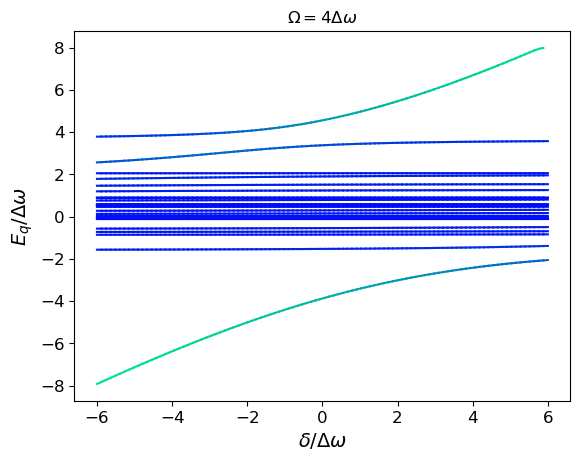

In [193]:
# Plot, color coding the lines according to the value of the photonic amplitudes
for j in range(ηqcs.shape[0]):
    c = cm.winter(ηqcs[j].real)
    for i in range(δ.shape[0]-1):
        plt.plot([δ[i], δ[i+1]], [Eqs[j][i], Eqs[j][i+1]], color=c[i])

plt.xlabel("$\\delta/\\Delta\\omega$")
plt.ylabel("$E_q/\\Delta\\omega$")
plt.title("$\\Omega=4\\Delta\\omega$")

So this looks pretty close to Fig. 2a in the Molmer paper.  The second line from the top is a bit off for some reason.  In the Molmer paper, it just goes straight across.  This might have to due with how I've defined $\delta$ and used it to calculate $E_q$ or it may be because I used only the real parts of the $\omega_j$'s.  It could also be because $\Delta\omega$ is too narrow compared to their paper or due to inaccuracies in obtaining the $E_q$'s.  I had to use a pretty loose tolerance and take the average in order to get arrays that weren't just empty and it may be that there's a better way of doing that.

In [194]:
# Get the values of Eq for the intermediate coupling regime
Eqi = np.zeros((ωjs.shape[0] + 1, δ.shape[0]), dtype=complex)
Eqi[0] = np.array([get_Eq(_, ωjs, gi, -8, ωjs.real[0]) for _ in δ])
for i in range(1, Eqi.shape[0]-1):
    Eqi[i] = np.array([get_Eq(_, ωjs, gi, ωjs.real[i-1]+1e-6, ωjs.real[i]) for _ in δ])
Eqi[-1] = np.array([get_Eq(_, ωjs, gi, ωjs.real[-1]+1e-6, 8) for _ in δ])

In [198]:
# Get the photonic amplitudes for the intermediate coupling regime
ηqci = np.zeros((ωjs.shape[0] + 1, δ.shape[0]), dtype=complex)
for i in range(ωjs.shape[0] + 1):
    ηqci[i] = get_ηqc(ωjs, Eqi[i], gi)

Text(0.5, 1.0, '$\\Omega=\\Delta\\omega$')

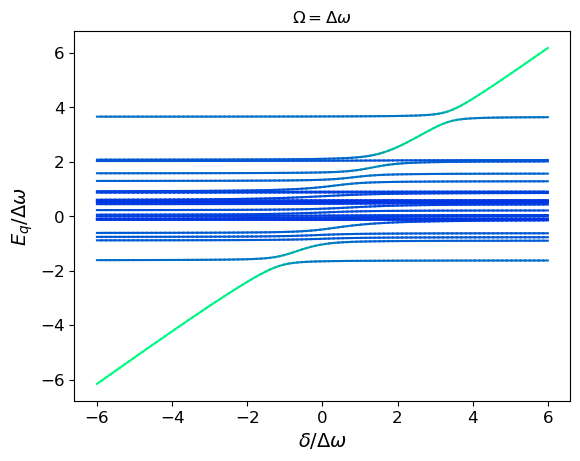

In [199]:
# Plot, color coding the lines according to the value of the photonic amplitudes
for j in range(ηqci.shape[0]):
    c = cm.winter(ηqci[j].real)
    for i in range(δ.shape[0]-1):
        plt.plot([δ[i], δ[i+1]], [Eqi[j][i], Eqi[j][i+1]], color=c[i])

plt.xlabel("$\\delta/\\Delta\\omega$")
plt.ylabel("$E_q/\\Delta\\omega$")
plt.title("$\\Omega=\\Delta\\omega$")

Same issue here.  It's close, but the interior lines should be more tightly packed together and not have as much variation as they do.

In [200]:
# Get the values of Eq for the weak coupling regime
Eqw = np.zeros((ωjs.shape[0] + 1, δ.shape[0]), dtype=complex)
Eqw[0] = np.array([get_Eq(_, ωjs, gw, -8, ωjs.real[0]) for _ in δ])
for i in range(1, Eqw.shape[0]-1):
    Eqw[i] = np.array([get_Eq(_, ωjs, gw, ωjs.real[i-1]+1e-6, ωjs.real[i]) for _ in δ])
Eqw[-1] = np.array([get_Eq(_, ωjs, gw, ωjs.real[-1]+1e-6, 8) for _ in δ])

In [201]:
# Get the photonic amplitudes for the weak coupling regime
ηqcw = np.zeros((ωjs.shape[0] + 1, δ.shape[0]), dtype=complex)
for i in range(ωjs.shape[0] + 1):
    ηqcw[i] = get_ηqc(ωjs, Eqw[i], gw)

Text(0.5, 1.0, '$\\Omega=\\Delta\\omega/4$')

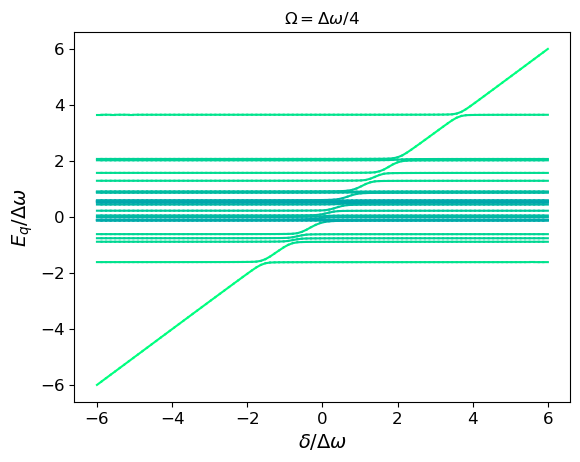

In [202]:
# Plot, color coding the lines according to the value of the photonic amplitudes
for j in range(ηqcw.shape[0]):
    c = cm.winter(ηqcw[j].real)
    for i in range(δ.shape[0]-1):
        plt.plot([δ[i], δ[i+1]], [Eqw[j][i], Eqw[j][i+1]], color=c[i])

plt.xlabel("$\\delta/\\Delta\\omega$")
plt.ylabel("$E_q/\\Delta\\omega$")
plt.title("$\\Omega=\\Delta\\omega/4$")